In [0]:
from pyspark.sql.functions import *
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = spark.table("cpg_sales_silver")
display(df.limit(5))

date,store_id,store_region,sku_id,category,units_sold,revenue,promo_flag,promo_type,price,inventory_level,store_size,holiday_flag,year,month,revenue_per_unit,is_promo
2022-11-19,3,East,118,Household,9,53.37,0,null,5.93,147,Medium,1,2022,11,5.93,false
2022-02-02,1,South,120,Personal Care,7,36.26,0,null,5.18,139,Large,0,2022,2,5.18,false
2022-03-26,9,South,149,Snacks,9,71.28,0,null,7.92,962,Large,1,2022,3,7.92,false
2022-03-18,9,East,106,Beverages,6,13.32,0,null,2.22,371,Medium,0,2022,3,2.22,false
2022-06-08,5,East,146,Household,10,65.5,0,null,6.55,229,Large,0,2022,6,6.55,false


### Monthly Revenue Trend

In [0]:
monthly_trend = df.groupBy("year", "month") \
    .agg(sum("revenue").alias("total_revenue")) \
    .orderBy("year", "month")

display(monthly_trend)

year,month,total_revenue
2022,1,29347.96800000001
2022,2,27141.912000000015
2022,3,29734.906000000014
2022,4,27473.498000000007
2022,5,26945.26000000002
2022,6,28800.138000000028
2022,7,30181.521999999964
2022,8,28082.593999999997
2022,9,27134.015999999996
2022,10,28696.149999999987


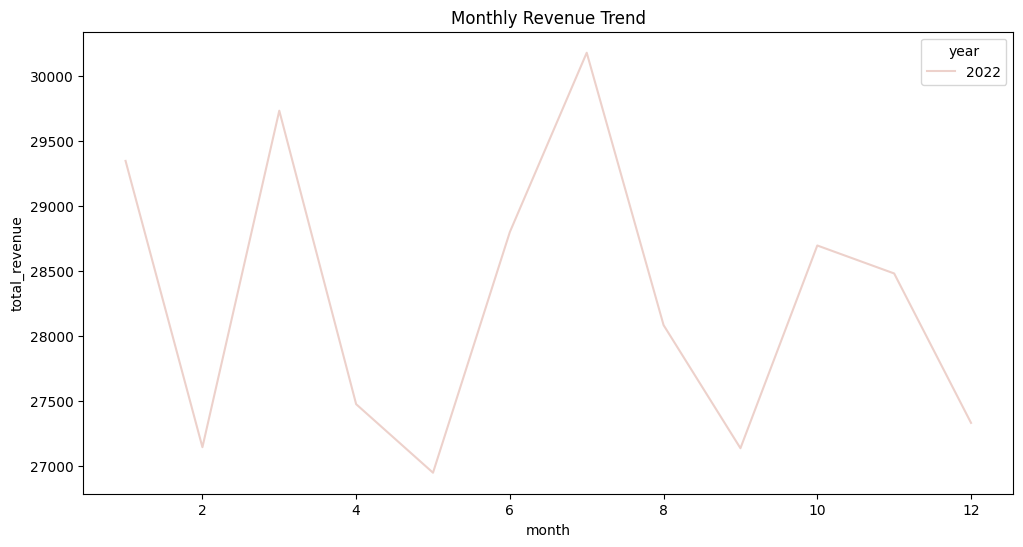

In [0]:
monthly_pdf = monthly_trend.toPandas()

plt.figure(figsize=(12,6))
sns.lineplot(data=monthly_pdf, x="month", y="total_revenue", hue="year")
plt.title("Monthly Revenue Trend")
plt.show()

### Moving Average Trend

In [0]:
from pyspark.sql.window import Window
from pyspark.sql.functions import avg

window = Window.partitionBy("year") \
    .orderBy("month") \
    .rowsBetween(-2, 0)

trend_df = monthly_trend.withColumn(
    "moving_avg",
    avg("total_revenue").over(window)
)

display(trend_df)

year,month,total_revenue,moving_avg
2022,1,29347.96800000001,29347.96800000001
2022,2,27141.912000000015,28244.940000000013
2022,3,29734.906000000014,28741.595333333345
2022,4,27473.498000000007,28116.77200000001
2022,5,26945.26000000002,28051.22133333335
2022,6,28800.138000000028,27739.632000000023
2022,7,30181.521999999964,28642.30666666667
2022,8,28082.593999999997,29021.417999999994
2022,9,27134.015999999996,28466.043999999983
2022,10,28696.149999999987,27970.919999999995


### Anomaly Detection

In [0]:
stats = df.select(
    avg("revenue").alias("mean"),
    stddev("revenue").alias("std")
).collect()[0]

mean_val = stats["mean"]
std_val = stats["std"]

print("Mean:", mean_val)
print("Std:", std_val)

Mean: 67.86958639999992
Std: 36.59663015726868


In [0]:
anomalies = df.withColumn(
    "z_score",
    (col("revenue") - mean_val) / std_val
).filter(abs(col("z_score")) > 3)

display(anomalies)

date,store_id,store_region,sku_id,category,units_sold,revenue,promo_flag,promo_type,price,inventory_level,store_size,holiday_flag,year,month,revenue_per_unit,is_promo,z_score
2022-01-31,2,South,139,Beverages,24,182.976,1,BuyOneGetOne,7.624,912,Medium,0,2022,1,7.624,true,3.1452735704174692
2022-07-08,8,East,123,Beverages,26,189.90400000000002,1,null,7.304000000000001,663,Large,0,2022,7,7.304000000000001,true,3.334580617821232
2022-09-17,9,East,131,Snacks,26,194.688,1,FlashSale,7.4879999999999995,169,Small,1,2022,9,7.4879999999999995,true,3.4653030362362993
2022-02-03,5,East,147,Dairy,29,210.888,1,Discount,7.272,381,Medium,0,2022,2,7.272,true,3.9079667440799692
2022-07-09,7,South,103,Snacks,30,210.24,1,BuyOneGetOne,7.008,418,Large,1,2022,7,7.008,true,3.890260195766223
2022-04-03,1,North,144,Beverages,27,191.16,1,FlashSale,7.08,392,Large,1,2022,4,7.08,true,3.368900717639234
2022-03-27,4,East,125,Beverages,23,180.32000000000002,1,null,7.840000000000001,553,Medium,1,2022,3,7.840000000000001,true,3.072698582267298
2022-03-15,4,East,146,Snacks,26,200.096,1,FlashSale,7.696,606,Large,0,2022,3,7.696,true,3.613076204879421
2022-12-21,6,North,140,Snacks,20,193.0,0,null,9.65,370,Small,0,2022,12,9.65,false,3.419178570875799
2022-02-22,1,North,106,Snacks,28,219.296,1,null,7.832,939,Small,0,2022,2,7.832,true,4.137714673434881


In [0]:
from pyspark.sql.functions import avg

silver_df = spark.table("cpg_sales_silver")

seasonality = (
    silver_df
    .groupBy("month")
    .agg(avg("revenue").alias("avg_monthly_revenue"))
    .orderBy("month")
)

display(seasonality)

month,avg_monthly_revenue
1,69.38053900709222
2,70.13413953488376
3,66.37255803571432
4,69.37752020202022
5,67.36315000000005
6,68.57175714285721
7,68.43882539682532
8,67.99659564164648
9,65.69979661016949
10,65.36708428246011


In [0]:
store_trend = df.groupBy("store_id","year","month") \
    .agg(sum("revenue").alias("total_revenue")) \
    .orderBy("store_id","year","month")

display(store_trend)

store_id,year,month,total_revenue
1,2022,1,2106.366
1,2022,2,2940.9500000000003
1,2022,3,2785.7759999999994
1,2022,4,2130.91
1,2022,5,2504.936
1,2022,6,2584.6399999999994
1,2022,7,2733.7860000000005
1,2022,8,3438.7220000000007
1,2022,9,2710.6179999999995
1,2022,10,2489.1760000000004


In [0]:
category_trend = df.groupBy("category","year","month") \
    .agg(sum("revenue").alias("total_revenue")) \
    .orderBy("category","year","month")

display(category_trend)

category,year,month,total_revenue
Beverages,2022,1,5371.853999999998
Beverages,2022,2,4264.3240000000005
Beverages,2022,3,5263.9259999999995
Beverages,2022,4,5913.320000000001
Beverages,2022,5,4606.4879999999985
Beverages,2022,6,6059.061999999999
Beverages,2022,7,5765.286
Beverages,2022,8,5107.949999999999
Beverages,2022,9,5927.932000000001
Beverages,2022,10,5413.740000000003
